Lab â€” MNIST Classifier: Target 97%+

Build, train, and evaluate a neural network on the full MNIST dataset. Visualise predictions, inspect the
confusion matrix, examine misclassified digits, and experiment with different architectures to understand how
design choices affect accuracy.

Complete Lab Code

11490434/11490434 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 0us/step


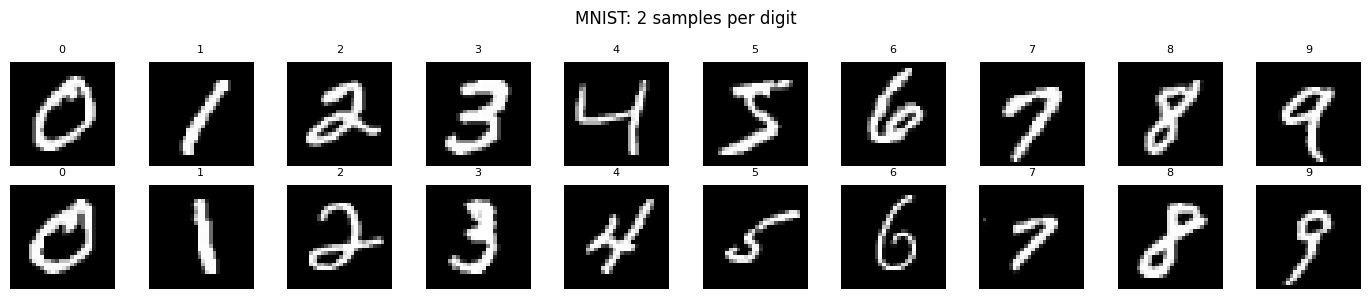

Model: "sequential"

â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”?â??â??â??
â?? Layer (type)                    â?? Output Shape           â??       Param # â??
â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
â?? dense (Dense)                   â?? (None, 256)            â??       200,960 â??
â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
â?? dropout (Dropout)               â?? (None, 256)            â??             0 â??
â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
â?? dense_1 (Dense)                 â?? (None, 128)            â??        32,896 â??
â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
â?? dropout_1 (Dropout)             â?? (None, 128)            â??             0 â??
â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
â?? dense_2 (Dense)                 â?? (None, 10)             â??         1,290 â??
â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
# â– â–  Load and preprocess MNIST â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– 
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0
# â– â–  Visualise a sample of training digits â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– 
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for d in range(10):
  for r, offset in enumerate([0, 1]):
    idx = np.where(y_train == d)[0][offset]
    axes[r, d].imshow(X_train[idx].reshape(28,28), cmap='gray')
    axes[r, d].set_title(str(d), fontsize=8); axes[r, d].axis('off')
plt.suptitle('MNIST: 2 samples per digit'); plt.tight_layout(); plt.show()
# â– â–  Build model as a reusable function â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– 
def make_model(h1=256, h2=128, drop=0.3):
  m = keras.Sequential([
  keras.Input(shape=(784,)),
  layers.Dense(h1, activation='relu'),
  layers.Dropout(drop),
  layers.Dense(h2, activation='relu'),
                       layers.Dropout(drop),
  layers.Dense(10, activation='softmax'),
  ])
  m.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])
  return m
model = make_model()
model.summary()

Epoch 1/30
422/422 â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â?? 9s 17ms/step - accuracy: 0.8760 - loss: 0.4079 - val_accuracy: 0.9650 - val_loss: 0.1250
Epoch 2/30
422/422 â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â?? 3s 8ms/step - accuracy: 0.9456 - loss: 0.1783 - val_accuracy: 0.9705 - val_loss: 0.0971
Epoch 3/30
422/422 â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â?? 2s 5ms/step - accuracy: 0.9599 - loss: 0.1310 - val_accuracy: 0.9782 - val_loss: 0.0771
Epoch 4/30
422/422 â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â?? 3s 6ms/step - accuracy: 0.9667 - loss: 0.1082 - val_accuracy: 0.9783 - val_loss: 0.0693
Epoch 5/30
422/422 â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â?? 2s 5ms/step - accuracy: 0.9720 - loss: 0.0904 - val_accuracy: 0.9807 - val_loss: 0.0667
Epoch 6/30
422/422 â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â?? 3s 5ms/step - accuracy: 0.9756 - loss: 0.0795 - val_accuracy: 0.9805 - val_loss

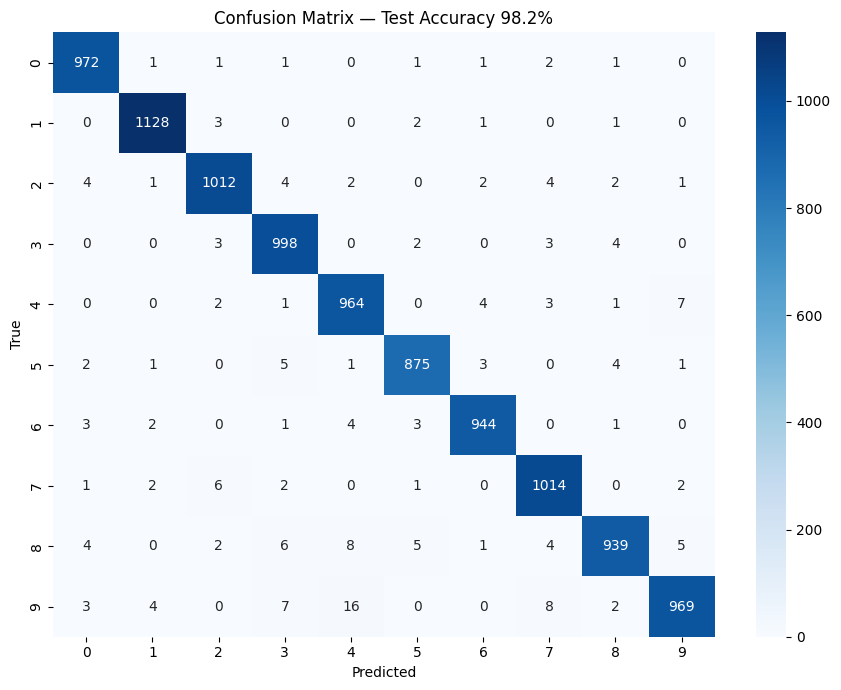

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

Misclassified: 185 out of 10000


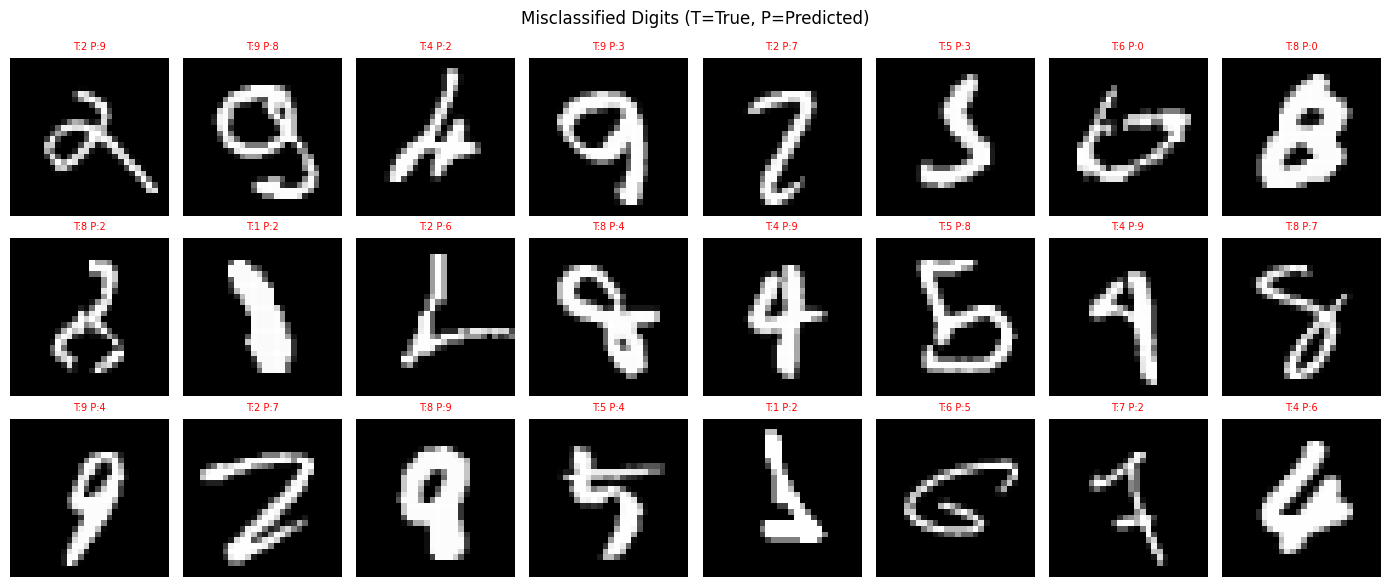

Large / moderate dropout            Accuracy: 98.02%


In [2]:
# â??â?? Train â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
history = model.fit(
X_train, y_train, epochs=30, batch_size=128,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=1)
# â??â?? Evaluate â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {acc*100:.2f}%')
# â??â?? Confusion matrix â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix â?? Test Accuracy {acc*100:.1f}%')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()
# Diagonal = correctly classified. Off-diagonal = confused pairs.
# Common confusions: 4 vs 9, 3 vs 8, 5 vs 6
print(classification_report(y_test, y_pred))
# â??â?? Show misclassified images â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
wrong = np.where(y_pred != y_test)[0]
print(f'Misclassified: {len(wrong)} out of {len(y_test)}')
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
  if i < len(wrong):
    idx = wrong[i]
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{y_pred[idx]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True, P=Predicted)')
plt.tight_layout(); plt.show()
# â??â?? Architecture comparison â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??â??
configs = [
(64, 32, 0.0, 'Small / no dropout'),
(128, 64, 0.2, 'Medium / light dropout'),
(256, 128, 0.3, 'Large / moderate dropout'),
]
for h1, h2, dr, label in configs:
  m = make_model(h1, h2, dr)
  m.fit(X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, verbose=0,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])
_, a = m.evaluate(X_test, y_test, verbose=0)
print(f'{label:35s} Accuracy: {a*100:.2f}%')

Bonus: Visualise What Neurons Learn

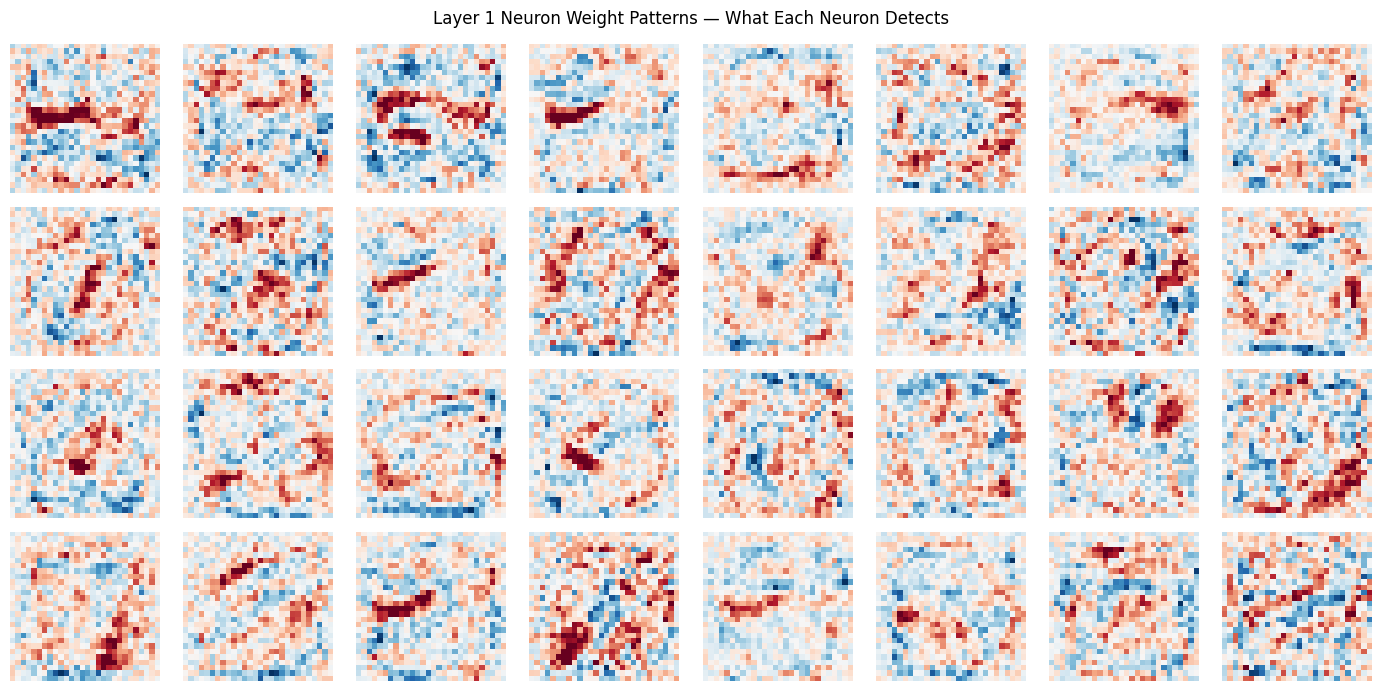

In [3]:
# â– â–  Each Layer 1 neuron has 784 weights (one per pixel) â– â– â– â– â– â– â– â– 
# Reshape to 28x28 to see which pixel patterns each neuron responds to
weights = model.layers[0].get_weights()[0] # shape: (784, 256)
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
  w = weights[:, i].reshape(28, 28)
  ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
  ax.axis('off')
plt.suptitle('Layer 1 Neuron Weight Patterns â€” What Each Neuron Detects')
plt.tight_layout(); plt.show()
# Blue = neuron activated strongly by bright pixel here
# Red = neuron suppressed by bright pixel here